# [실습 3-1] 미로 탐색 — BFS/DFS 구현과 탐색 범위 시각화

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 3.2 무정보 탐색 |
| 선수 실습 | 없음 |
| 준비 | 부록 B.1(Colab 시작)·B.3(라이브러리 기초) 참고 |

같은 미로를 너비 우선 탐색(BFS)과 깊이 우선 탐색(DFS)으로 풀고,
두 알고리즘이 미로를 **어떻게 다르게 훑는지** 눈으로 확인한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs/notebooks
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch03/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import matplotlib
import numpy as np
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ Matplotlib", matplotlib.__version__)

Python 3.12.6
NumPy 2.4.6 / Matplotlib 3.10.9


### [셀 1] 미로 정의 📖

In [2]:
# 0 = 통로, 1 = 벽. 문자열로 그려서 읽기 쉽게 정의한다.
MAZE_MAP = [
    "S......#.......",
    "......##.......",
    "...............",
    "..###....###...",
    "..#........#...",
    "..#..####..#...",
    ".....#..#......",
    "..#..#..#..#...",
    "..#..####..#...",
    "..#........#...",
    "..###....###...",
    "...............",
    ".......##......",
    "........#......",
    "..............G",
]
grid = [[1 if ch == "#" else 0 for ch in row]
        for row in MAZE_MAP]
START, GOAL = (0, 0), (14, 14)
print(f"미로 크기: {len(grid)} x {len(grid[0])}")

미로 크기: 15 x 15


**핵심 포인트**
- 상태 공간 정형화(3.1): 상태 = (행, 열) 좌표, 목표 검사 = `GOAL` 도달.
- 미로를 문자열 그림으로 정의하면 벽(`#`)의 배치를 눈으로 바로 확인할 수 있다.

기대 출력: `미로 크기: 15 x 15`

### [셀 2] 이동 규칙과 경로 복원 📖

In [3]:
def neighbors(pos):
    """상하좌우 중 벽이 아닌 이웃 칸(연산자 적용 결과)."""
    r, c = pos
    for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        nr, nc = r + dr, c + dc
        if (0 <= nr < len(grid) and 0 <= nc < len(grid[0])
                and grid[nr][nc] == 0):
            yield (nr, nc)

def build_path(parent, goal):
    """parent 기록을 거슬러 올라 경로를 복원한다."""
    if goal not in parent:
        return []               # 경로를 찾지 못한 경우
    path, node = [], goal
    while node is not None:
        path.append(node)
        node = parent[node]
    return path[::-1]

**핵심 포인트**
- `neighbors()`가 3.1의 **연산자**(이동 규칙), `parent` 딕셔너리가 경로 기억 장치다.
- 탐색이 끝난 뒤 `parent`를 목표에서 시작점까지 거슬러 올라가면 경로가 나온다.

### [셀 3] 너비 우선 탐색(BFS) 📖

In [4]:
from collections import deque

def bfs(start, goal):
    """프론티어를 큐(FIFO)로 관리 — 얕은 곳부터 훑는다."""
    frontier = deque([start])
    parent = {start: None}      # 방문 기록 겸 경로 기억
    while frontier:
        node = frontier.popleft()   # 앞에서 꺼낸다
        if node == goal:
            break
        for nxt in neighbors(node):
            if nxt not in parent:
                parent[nxt] = node
                frontier.append(nxt)
    return parent

bfs_parent = bfs(START, GOAL)
bfs_path = build_path(bfs_parent, GOAL)
print(f"BFS: 방문 {len(bfs_parent)}칸, "
      f"경로 {len(bfs_path)}칸")

BFS: 방문 181칸, 경로 29칸


**핵심 포인트**
- 프론티어가 **큐**이므로 시작점에서 가까운 칸부터 층층이 확장한다 → 찾은 경로는 **최단**이다(3.2.1).
- `parent`에 없는 칸만 프론티어에 넣는 것이 중복 방문 차단 장치다.

기대 출력: `BFS: 방문 181칸, 경로 29칸`

실패 시 대처: `NameError: neighbors`가 나오면 [셀 2]를 먼저 실행했는지 확인한다.

### [셀 4] 깊이 우선 탐색(DFS) 📖

In [5]:
def dfs(start, goal):
    """프론티어를 스택(LIFO)으로 — 한 갈래를 깊이 판다."""
    frontier = [start]
    parent = {start: None}
    while frontier:
        node = frontier.pop()   # 뒤에서 꺼낸다(유일한 차이)
        if node == goal:
            break
        for nxt in neighbors(node):
            if nxt not in parent:
                parent[nxt] = node
                frontier.append(nxt)
    return parent

dfs_parent = dfs(START, GOAL)
dfs_path = build_path(dfs_parent, GOAL)
print(f"DFS: 방문 {len(dfs_parent)}칸, "
      f"경로 {len(dfs_path)}칸")

DFS: 방문 85칸, 경로 47칸


**핵심 포인트**
- BFS와의 차이는 `popleft()` → `pop()` **단 한 줄**. 자료구조(큐→스택)가 탐색의 성격을 통째로 바꾼다(3.2.2).
- DFS는 방문 칸이 적을 수 있지만 경로의 최단성은 **보장하지 않는다**.

기대 출력: `DFS: 방문 85칸, 경로 47칸` — BFS(29칸)보다 훨씬 긴 경로다.

### [셀 5] 탐색 범위 시각화 📖

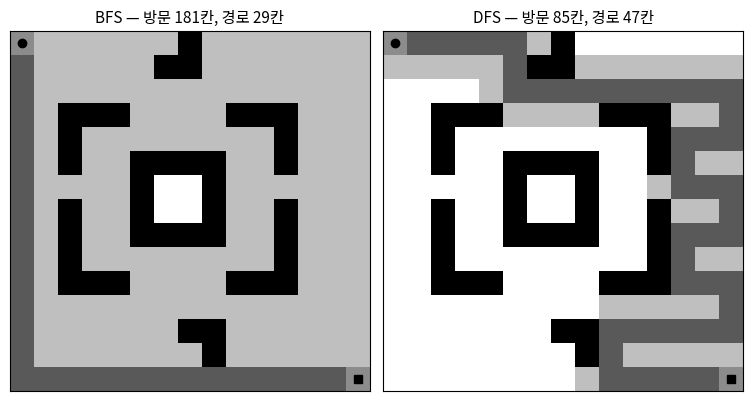

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(7.6, 4))
viz.draw_maze_search(
    grid, bfs_parent, bfs_path, START, GOAL,
    title=f"BFS — 방문 {len(bfs_parent)}칸, "
          f"경로 {len(bfs_path)}칸", ax=axes[0])
viz.draw_maze_search(
    grid, dfs_parent, dfs_path, START, GOAL,
    title=f"DFS — 방문 {len(dfs_parent)}칸, "
          f"경로 {len(dfs_path)}칸", ax=axes[1])
plt.tight_layout()
plt.show()

**핵심 포인트**
- 연한 회색 = 방문한 칸, 진한 회색 = 최종 경로. BFS는 시작점 주위를 **동심원처럼** 넓게 훑고, DFS는 **한 갈래로 깊이** 파고든다.
- 시각화 함수 본체는 `utils/viz.py`에 있다(지면 25줄 상한 — 코드 정책 ③).

실패 시 대처: 한글이 □로 보이면 [준비] 셀을 다시 실행한 뒤 메뉴에서 "런타임 다시 시작"을 한다.

### [보조 1] BFS vs DFS vs A* 3연도 — 지면 [그림 3-x]와 동일 구도\n\nA\*는 다음 실습(3-2)에서 자세히 구현한다. 여기서는 미리보기로 세 알고리즘의 탐색 범위를 나란히 비교한다.

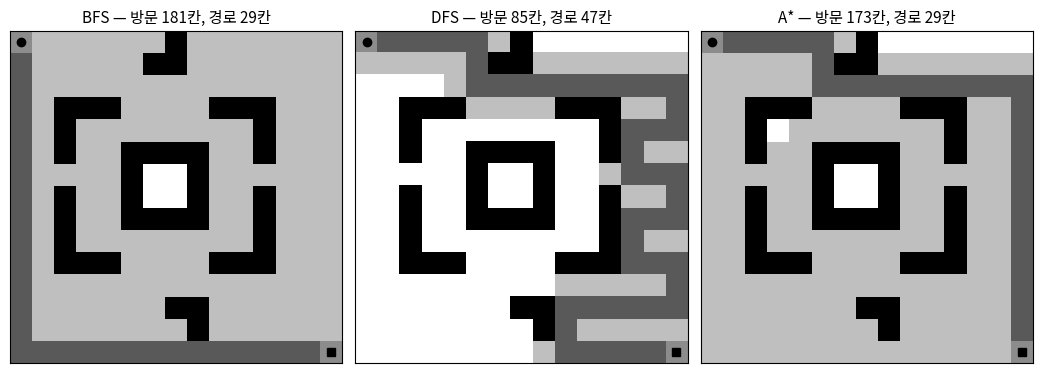

In [7]:
import heapq

def astar_maze(start, goal):
    def h(p):                   # 맨해튼 거리 휴리스틱
        return abs(p[0] - goal[0]) + abs(p[1] - goal[1])
    frontier = [(h(start), 0, start)]
    parent, g = {start: None}, {start: 0}
    while frontier:
        _, cost, node = heapq.heappop(frontier)
        if node == goal:
            break
        for nxt in neighbors(node):
            ng = cost + 1
            if nxt not in g or ng < g[nxt]:
                g[nxt], parent[nxt] = ng, node
                heapq.heappush(frontier,
                               (ng + h(nxt), ng, nxt))
    return parent

ast_parent = astar_maze(START, GOAL)
ast_path = build_path(ast_parent, GOAL)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.8))
runs = [("BFS", bfs_parent, bfs_path),
        ("DFS", dfs_parent, dfs_path),
        ("A*", ast_parent, ast_path)]
for ax, (name, par, path) in zip(axes, runs):
    viz.draw_maze_search(
        grid, par, path, START, GOAL, ax=ax,
        title=f"{name} — 방문 {len(par)}칸, "
              f"경로 {len(path)}칸")
plt.tight_layout()
plt.show()

### [심화 1] 미로 변형 실험 (연습문제 심화 연계)

In [8]:
# 연습문제 심화 문항 연계 — 미로를 바꿔 가설을 검증해 보자.
# 1) MAZE_MAP을 복사해 벽(#)·통로(.)를 수정한다
# 2) [셀 1]부터 재실행해 방문 칸 수 변화를 기록한다
# 가설 예: "목표가 시작점 바로 아래에 있으면
#           DFS가 BFS보다 방문 칸이 적을까?"
MY_MAZE = list(MAZE_MAP)        # 여기를 수정한 뒤
# grid = [[1 if ch == "#" else 0 for ch in row]
#         for row in MY_MAZE]   # 주석을 해제하고 재실행
print("미로를 수정한 뒤 주석을 해제하고 재실행하세요.")

미로를 수정한 뒤 주석을 해제하고 재실행하세요.


---
## 마무리

- **프론티어 자료구조가 곧 탐색 전략이다**: 큐(BFS)는 최단 경로를 보장하고, 스택(DFS)은 메모리가 절약되지만 경로가 길어질 수 있다.
- 방문 기록(`parent`)은 중복 방문을 막는 동시에 경로 복원 장치가 된다.
- 두 알고리즘 모두 목표까지의 "거리 감각" 없이 훑는다 — 이 한계를 다음 실습의 A\*가 해결한다.

**연습문제 연계**: 장말 연습문제의 [응용] BFS/DFS 탐색 순서 추적 문항은 이 노트북의 미로보다 작은 5×5 예제로 손으로 풀어 본 뒤, [심화 1] 셀로 검증할 수 있다.

**다음 실습**: [실습 3-2] 8-퍼즐 A\* — 휴리스틱 2종 성능 비교 (`lab-03-02_eight-puzzle-astar.ipynb`)